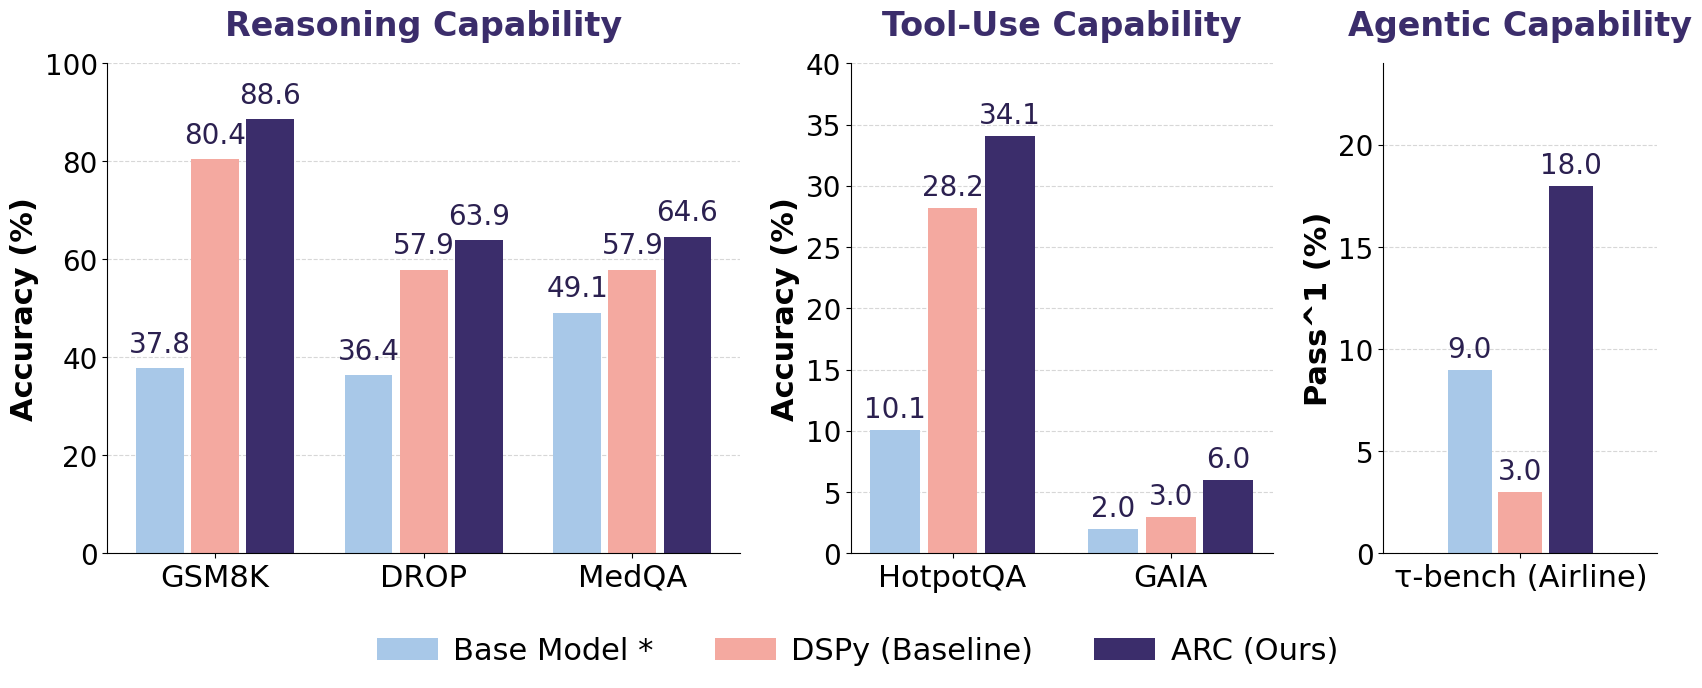

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- Colors from the first version (same across all plots) ---
colors = ['#A8C8E8', '#F4A9A0', '#3B2D6B']  # light blue, salmon, dark purple
methods = ["Base Model *", "DSPy (Baseline)", "ARC (Ours)"]

# --- Data ---
reasoning_tasks = ["GSM8K", "DROP", "MedQA"]
reasoning_data = [
    [37.8, 36.4, 49.1],
    [80.4, 57.9, 57.9],
    [88.6, 63.9, 64.6]
]

tool_tasks = ["HotpotQA", "GAIA"]
tool_data = [
    [10.1, 2.0],
    [28.2, 3.0],
    [34.1, 6.0]
]

agentic_tasks = ["\u03C4-bench (Airline)"]
agentic_data = [
    [9.0],
    [3.0],
    [18.0]
]

# --- Figure ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7),
                                     gridspec_kw={'width_ratios': [3, 2, 1.3], 'wspace': 0.25})

bar_width = 0.16
group_gap = 0.22  # extra space between groups

def style_ax(ax):
    """Remove top/right spines, add dotted y-grid."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)

def plot_bars(ax, tasks, data, ylim, ylabel, title, text_offset):
    n_groups = len(tasks)
    x = np.arange(n_groups) * (3 * bar_width + group_gap)

    for i, method_data in enumerate(data):
        pos = x + (i - 1) * (bar_width + 0.025)  # center bars around group position
        bars = ax.bar(pos, method_data, width=bar_width,
                      color=colors[i], edgecolor='none', linewidth=0)
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2., h + text_offset,
                    f'{h}', ha='center', va='bottom', fontsize=20,
                    color='#2B2050')

    ax.set_xticks(x)
    ax.set_xticklabels(tasks, fontsize=22)
    ax.set_ylim(0, ylim)
    ax.set_ylabel(ylabel, fontsize=22, fontweight='bold')
    ax.set_title(title, fontsize=24, fontweight='bold', color='#3B2D6B', pad=20)
    ax.tick_params(axis='y', labelsize=20)
    style_ax(ax)

# --- Plot 1: Reasoning ---
plot_bars(ax1, reasoning_tasks, reasoning_data, 100,
          "Accuracy (%)", "Reasoning Capability", 2)

# --- Plot 2: Tool-Use ---
plot_bars(ax2, tool_tasks, tool_data, 40,
          "Accuracy (%)", "Tool-Use Capability", 0.5)

# --- Plot 3: Agentic Task ---
plot_bars(ax3, agentic_tasks, agentic_data, 24,
          "Pass^1 (%)", "Agentic Capability", 0.3)
ax3.set_xlim(-0.5, 0.5)

# --- Legend ---
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, edgecolor='none') for c in colors]
fig.legend(handles, methods, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), fontsize=22, frameon=False,
           handletextpad=0.5, columnspacing=2.0)

plt.subplots_adjust(bottom=0.18)
# plt.savefig('/mnt/user-data/outputs/results_plot.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('/mnt/user-data/outputs/results_plot.png', dpi=300, bbox_inches='tight')
plt.show()

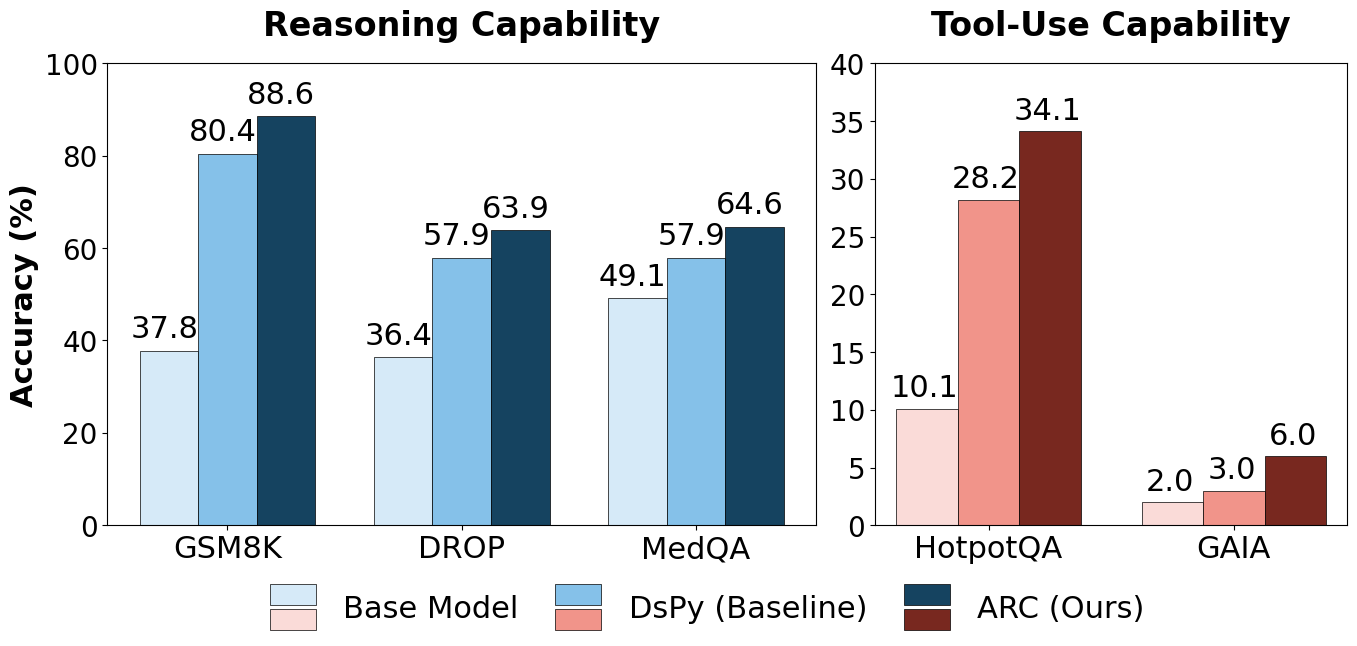

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase
import numpy as np

# --- 1. Robust Custom Handler ---
class VerticalSplitHandler(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize,
                       trans):
        b1, b2 = orig_handle
        color_top = b1.get_facecolor()
        color_bottom = b2.get_facecolor()
        
        # Dimensions based on fontsize
        box_width = fontsize * 1.5
        total_height = fontsize * 1.5
        gap = total_height * 0.1
        single_box_height = (total_height - gap) / 2
        
        y_center = ydescent + (height / 2)
        
        p_top = mpatches.Rectangle(
            (xdescent, y_center + gap/2), box_width, single_box_height,
            facecolor=color_top, edgecolor='black', linewidth=0.5,
            transform=trans
        )
        
        p_bottom = mpatches.Rectangle(
            (xdescent, y_center - gap/2 - single_box_height), box_width, single_box_height,
            facecolor=color_bottom, edgecolor='black', linewidth=0.5,
            transform=trans
        )
        
        return [p_top, p_bottom]

# --- 2. Data Setup ---
methods = ["Base Model", "DsPy (Baseline)", "ARC (Ours)"]

reasoning_tasks = ["GSM8K", "DROP", "MedQA"]
reasoning_data = [
    [37.8, 36.4, 49.1],
    [80.4, 57.9, 57.9],
    # [87.6, 62.3, 58.4],
    [88.6, 63.9, 64.6]
]

tool_tasks = ["HotpotQA", "GAIA"]
tool_data = [
    [10.1, 2.0],
    [28.2, 3.0],
    # [33.7, 5.0],
    [34.1, 6.0]
]

colors_reasoning = ['#D6EAF8', '#85C1E9', '#154360'] # '#3498DB'
colors_tool = ['#FADBD8', '#F1948A', '#78281F'] # '#E74C3C'

# --- 3. Plotting ---
# INCREASED WIDTH: figsize=(16, 7) gives the bars more room to breathe
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), 
                               gridspec_kw={'width_ratios': [3, 2], 'wspace': 0.1})
bar_width = 0.25

bars_reasoning = []
bars_tool = []

# --- Plot 1: Reasoning ---
x = np.arange(len(reasoning_tasks))
for i, method_data in enumerate(reasoning_data):
    pos = x + (i * bar_width) - (1.5 * bar_width)
    bar = ax1.bar(pos, method_data, width=bar_width, 
                  color=colors_reasoning[i], edgecolor='black', linewidth=0.5)
    bars_reasoning.append(bar) 
    
    for b in bar:
        height = b.get_height()
        # Adjusted font to 13 bold (readable but smaller than 16 to avoid overlap)
        ax1.text(b.get_x() + b.get_width()/2. - 0.02, height + 1.5,
                 f'{height}', ha='center', va='bottom', fontsize=22)

ax1.set_title("Reasoning Capability", fontsize=24, fontweight='bold', pad=20)
ax1.set_xticks(x - 0.5 * bar_width)
ax1.set_xticklabels(reasoning_tasks, fontsize=22)
ax1.set_ylabel("Accuracy (%)", fontsize=22, fontweight='bold')
ax1.set_ylim(0, 100) # Increased limit for headroom
ax1.tick_params(axis='y', labelsize=20)

# --- Plot 2: Tool Use ---
x2 = np.arange(len(tool_tasks))
for i, method_data in enumerate(tool_data):
    pos = x2 + (i * bar_width) - (1.5 * bar_width)
    bar = ax2.bar(pos, method_data, width=bar_width, 
                  color=colors_tool[i], edgecolor='black', linewidth=0.5)
    bars_tool.append(bar) 
    
    for b in bar:
        height = b.get_height()
        # Adjusted font to 13 bold
        ax2.text(b.get_x() + b.get_width()/2. - 0.01, height + 0.5,
                 f'{height}', ha='center', va='bottom', fontsize=22)

ax2.set_title("Tool-Use Capability", fontsize=24, fontweight='bold', pad=20)
ax2.set_xticks(x2 - 0.5 * bar_width)
ax2.set_xticklabels(tool_tasks, fontsize=22)
ax2.set_ylim(0, 40) # Increased limit for headroom
ax2.tick_params(axis='y', labelsize=20)

# --- 4. Layout & Legend ---
plt.subplots_adjust(bottom=0.22) 

legend_handles = list(zip([b[0] for b in bars_reasoning], [b[0] for b in bars_tool]))

fig.legend(
    handles=legend_handles,
    labels=methods,
    loc='lower center', 
    ncol=4, 
    bbox_to_anchor=(0.5, 0.04), 
    fontsize=22, 
    frameon=False,
    handletextpad=0.4, 
    columnspacing=1.2, 
    handler_map={tuple: VerticalSplitHandler()}
)

plt.show()

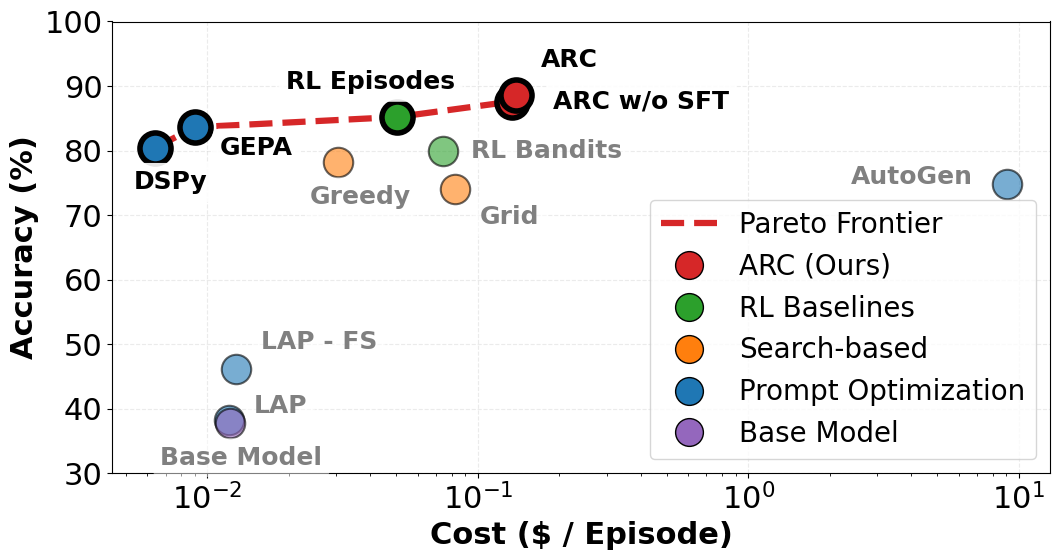

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data
# -----------------------------
data = {
    'Method': ['ARC', 'ARC w/o SFT', 'RL Episodes', 'GEPA', 'DSPy',
                'RL Bandits', 'Greedy', 'AutoGen', 'Grid',
                'Base Model', 'LAP - FS', 'LAP'],
    'Accuracy': [88.60, 87.60, 85.20, 83.62, 80.44, 80.00,
                78.20, 74.80, 74.00, 37.80, 46.10, 38.30],
    'Cost': [0.1382, 0.1335, 0.0503, 0.0090, 0.0064, 0.0742,
            .0304, 9.0797, 0.0823, 0.0121, 0.0128, 0.0120]
}
df = pd.DataFrame(data)

# -----------------------------
# Category mapping (from experiment.tex)
# -----------------------------
category_colors = {
    'Our Method': '#D62728',  # Red - HRL, HRL + SFT
    'RL Baselines': '#2CA02C',  # Green - RL Bandits, RL Episodes
    'Search-based': '#FF7F0E',  # Orange - Grid, Greedy
    'Prompt Optimization': '#1F77B4',  # Blue - AutoGen, DsPy, GEPA, LAP, LAP - FS
    'Base Model': '#9467BD'  # Purple - Base Model
}

method_categories = {
    'ARC': 'Our Method',
    'ARC w/o SFT': 'Our Method',
    'RL Episodes': 'RL Baselines',
    'RL Bandits': 'RL Baselines',
    'Grid': 'Search-based',
    'Greedy': 'Search-based',
    'AutoGen': 'Prompt Optimization',
    'DSPy': 'Prompt Optimization',
    'GEPA': 'Prompt Optimization',
    'LAP': 'Prompt Optimization',
    'LAP - FS': 'Prompt Optimization',
    'Base Model': 'Base Model'
}

# Add category and color to dataframe
df['Category'] = df['Method'].map(method_categories)
df['Color'] = df['Category'].map(category_colors)

# -----------------------------
# Pareto frontier
# -----------------------------
def get_pareto_front(costs, accuracies):
    n = len(costs)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if j == i:
                continue
            if (accuracies[j] >= accuracies[i]) and (costs[j] <= costs[i]) and (
                (accuracies[j] > accuracies[i]) or (costs[j] < costs[i])
            ):
                is_pareto[i] = False
                break
    return is_pareto

df['Is Pareto'] = get_pareto_front(df['Cost'].values, df['Accuracy'].values)

pareto = df[df['Is Pareto']].sort_values('Cost')
non_pareto = df[~df['Is Pareto']]

# -----------------------------
# Plot style
# -----------------------------
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 22,
    'axes.titlesize': 22,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 20,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})

fig, ax = plt.subplots(figsize=(11, 6))

# -----------------------------
# Scatter by category
# -----------------------------
# Plot non-Pareto points by category
for category in df['Category'].unique():
    category_data = non_pareto[non_pareto['Category'] == category]
    if len(category_data) > 0:
        ax.scatter(
            category_data['Cost'], category_data['Accuracy'],
            s=450, color=category_colors[category], edgecolor='black',
            alpha=0.6, zorder=2, linewidth=1.5
        )

# Plot Pareto points by category (highlighted)
for category in df['Category'].unique():
    category_data = pareto[pareto['Category'] == category]
    if len(category_data) > 0:
        # First draw a white halo for emphasis
        ax.scatter(
            category_data['Cost'], category_data['Accuracy'],
            s=600, color='white', edgecolor='none',
            alpha=0.8, zorder=4
        )
        # Then draw the colored point with thick border
        ax.scatter(
            category_data['Cost'], category_data['Accuracy'],
            s=500, color=category_colors[category], edgecolor='black',
            linewidth=4, zorder=6, marker='o'
        )

# Plot Pareto frontier line (bolder and more visible)
ax.plot(
    pareto['Cost'], pareto['Accuracy'],
    linestyle='--', linewidth=4.5,
    color='#D62728', alpha=1.0, zorder=4, label='Pareto Frontier'
)

# Log scale
ax.set_xscale('log')

ax.set_xlabel('Cost ($ / Episode)', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_ylim(30, 100)  # Set y-axis to show from 0 to 100
# ax.set_title('Accuracy vs Cost — Pareto Frontier', pad=14)



# -----------------------------
# Labels (simple, clean)
# -----------------------------
label_offsets = {
    'ARC': (18, 25),      # Top right, above point
    'ARC w/o SFT': (30, 0),           # Bottom right, below point
    'RL Episodes': (-80, 25),   # Bottom right
    'GEPA': (18, -15),          # Slightly below, different from DSPy
    'DSPy': (-15, -25),          # Further below to separate from GEPA
    'RL Bandits': (20, 0),     # Top right
    'Greedy': (-20, -25), # Further down
    'Grid': (18, -20),   # Between others
    'Base Model': (-50, -25),     # Higher up to separate from LAP methods
    'LAP - FS': (18, 20),       # Middle position
    'LAP': (18, 10),            # Lower than LAP - FS
    'AutoGen': (-25, 5),        # Further left, slightly up
}

for _, row in df.iterrows():
    name = row['Method']
    dx, dy = label_offsets.get(name, (8, 4))
    # Lighten labels for non-Pareto models
    is_pareto = row['Is Pareto']
    label_alpha = 0.5 if not is_pareto else 0.9
    label_color = 'gray' if not is_pareto else 'black'

    ax.annotate(
        name,
        xy=(row['Cost'], row['Accuracy']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=18,
        fontweight='bold',
        ha='right' if name == 'AutoGen' else 'left',
        va='center',
        color=label_color,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=label_alpha),
        zorder=6
    )

# -----------------------------
# Legend & save
# -----------------------------
# Create custom legend with categories
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], linestyle='--', color='#D62728', linewidth=4.5, label='Pareto Frontier'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors['Our Method'],
           markersize=20, markeredgecolor='black', markeredgewidth=1, label='ARC (Ours)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors['RL Baselines'],
           markersize=20, markeredgecolor='black', markeredgewidth=1, label='RL Baselines'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors['Search-based'],
           markersize=20, markeredgecolor='black', markeredgewidth=1, label='Search-based'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors['Prompt Optimization'],
           markersize=20, markeredgecolor='black', markeredgewidth=1, label='Prompt Optimization'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors['Base Model'],
           markersize=20, markeredgecolor='black', markeredgewidth=1, label='Base Model')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=20)
plt.tight_layout()
plt.savefig('pareto_frontier_AC.pdf', dpi=1200, bbox_inches='tight')
plt.show()

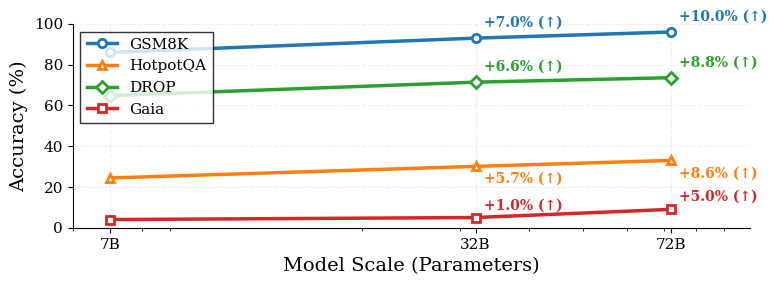

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Data Setup
# -----------------------------
qwen_sizes = np.array([7, 32, 72])

gsm8k_acc  = np.array([86, 93, 96])
hotpot_acc = np.array([24.4, 30.1, 33.0])
drop_acc   = np.array([64.8, 71.4, 73.6])
gaia_acc   = np.array([4, 5, 9])

# Absolute improvement over 7B
def abs_improve(acc):
    base = acc[0]
    return acc[1:] - base

gsm8k_diff  = abs_improve(gsm8k_acc)
hotpot_diff = abs_improve(hotpot_acc)
drop_diff   = abs_improve(drop_acc)
gaia_diff   = abs_improve(gaia_acc)

# -----------------------------
# 2. ICML Styling
# -----------------------------
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'font.family': 'serif',
    'axes.grid': True,
    'grid.alpha': 0.2,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(8, 3))

# -----------------------------
# 3. Plot lines
# -----------------------------
gsm_line, = ax.plot(
    qwen_sizes, gsm8k_acc,
    marker='o', linewidth=2.5,
    label='GSM8K',
    markerfacecolor='white', markeredgewidth=2
)

hotpot_line, = ax.plot(
    qwen_sizes, hotpot_acc,
    marker='^', linewidth=2.5,
    label='HotpotQA',
    markerfacecolor='white', markeredgewidth=2
)

drop_line, = ax.plot(
    qwen_sizes, drop_acc,
    marker='D', linewidth=2.5,
    label='DROP',
    markerfacecolor='white', markeredgewidth=2
)

gaia_line, = ax.plot(
    qwen_sizes, gaia_acc,
    marker='s', linewidth=2.5,
    label='Gaia',
    markerfacecolor='white', markeredgewidth=2
)

# -----------------------------
# 4. Absolute +Δ annotations (colored by line)
# -----------------------------
datasets = [
    (gsm8k_acc,  gsm8k_diff,  gsm_line.get_color(),  (6, 8)),
    (hotpot_acc, hotpot_diff, hotpot_line.get_color(), (6, -12)),
    (drop_acc,   drop_diff,   drop_line.get_color(),   (6, 8)),
    (gaia_acc,   gaia_diff,   gaia_line.get_color(),   (6, 6)),
]

for acc, diff, color, (dx, dy) in datasets:
    for i, (x, y) in enumerate(zip(qwen_sizes[1:], acc[1:])):
        ax.annotate(
            f'+{diff[i]:.1f}% (↑)',
            (x, y),
            textcoords='offset points',
            xytext=(dx, dy),
            ha='left',
            fontsize=10,
            color=color,
            fontweight='bold'
        )

# -----------------------------
# 5. Axis formatting
# -----------------------------
ax.set_xscale('log')
ax.set_xlabel('Model Scale (Parameters)')
ax.set_ylabel('Accuracy (%)')

ax.set_xticks([7, 32, 72])
ax.set_xticklabels(['7B', '32B', '72B'])

ax.set_ylim(0, 100)
ax.set_xlim(6, 100)

ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')

plt.tight_layout()
plt.savefig('scaling_trend_final.pdf', bbox_inches='tight')
plt.show()

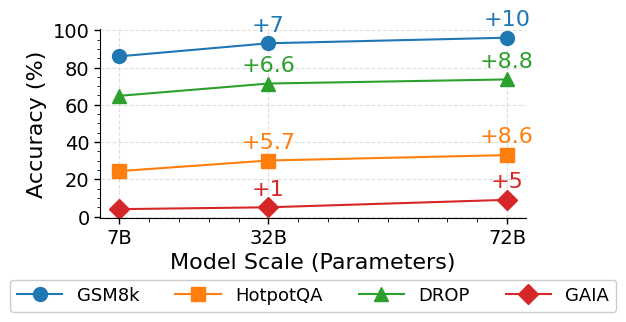

In [27]:
import matplotlib.pyplot as plt
import numpy as np

qwen_sizes = np.array([7, 32, 72])

gsm8k_acc  = np.array([86, 93, 96])
hotpot_acc = np.array([24.4, 30.1, 33.0])
drop_acc   = np.array([64.8, 71.4, 73.6])
gaia_acc   = np.array([4, 5, 9])

fig, ax = plt.subplots(figsize=(6., 3.25))

ax.plot(qwen_sizes, gsm8k_acc, marker='o', label='GSM8k', markersize=10)
ax.plot(qwen_sizes, hotpot_acc, marker='s', label='HotpotQA', markersize=10)
ax.plot(qwen_sizes, drop_acc, marker='^', label='DROP', markersize=10)
ax.plot(qwen_sizes, gaia_acc, marker='D', label='GAIA', markersize=10)

ax.set_xlabel("Model Scale (Parameters)", fontsize=16)
ax.set_ylabel("Accuracy (%)", fontsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', length=4, width=1)
ax.set_xticks(qwen_sizes)
ax.set_xticklabels([f"{s}B" for s in qwen_sizes], fontsize=14)

ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels(np.arange(0, 101, 20), fontsize=14)

ax.minorticks_on()
ax.tick_params(axis='x', which='minor', length=3)

ax.grid(True, linestyle='--', alpha=0.4)


# Legend with a light box + rounded corners
leg = plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=4,
    frameon=True,
    fancybox=True,
    handlelength=2.5,
    fontsize=13
)
frame = leg.get_frame()
frame.set_alpha(1)          # light fill
frame.set_linewidth(1)       # subtle border

# Annotate deltas vs 7B (skip first point)
series = [
    ("GSM8k", gsm8k_acc),
    ("HotpotQA", hotpot_acc),
    ("DROP", drop_acc),
    ("GAIA", gaia_acc),
]

# small offsets to reduce overlap between series at same x
x_offsets = {"GSM8k": -0.8, "HotpotQA": -0.2, "DROP": 0.3, "GAIA": 0.8}
x_colors = {"GSM8k": "#1F77B4", "HotpotQA": "#FF7F0E", "DROP": "#2CA02C", "GAIA": "#D62728"}

for name, y in series:
    base = y[0]
    for i in range(1, len(qwen_sizes)):
        delta = y[i] - base
        # show sign, compact (e.g., +7, +5.7)
        # use 1 decimal only if needed
        if abs(delta - round(delta)) < 1e-9:
            txt = f"{delta:+.0f}"
        else:
            txt = f"{delta:+.1f}"
        ax.annotate(
            txt,
            (qwen_sizes[i], y[i]),
            textcoords="offset points",
            xytext=(0, 6),   # above marker
            ha="center",
            va="bottom",
            fontsize=16,
            color=x_colors[name]
        )

fig.subplots_adjust(bottom=0.4)
plt.tight_layout()

plt.savefig('scaling_trend.pdf', bbox_inches='tight')
plt.show()

In [28]:
import numpy as np
from scipy.stats import kendalltau, pearsonr

qwen_sizes = np.array([7, 32, 72])

datasets = {
    "GSM8k": np.array([86, 93, 96]),
    "HotpotQA": np.array([24.4, 30.1, 33.0]),
    "DROP": np.array([64.8, 71.4, 73.6]),
    "GAIA": np.array([4, 5, 9]),
}

results = {}

for name, acc in datasets.items():
    kt, _ = kendalltau(qwen_sizes, acc)
    pr, _ = pearsonr(qwen_sizes, acc)
    results[name] = (kt, pr)

avg_kendall = np.mean([v[0] for v in results.values()])
avg_pearson = np.mean([v[1] for v in results.values()])

results, avg_kendall, avg_pearson


({'GSM8k': (np.float64(1.0), np.float64(0.9361025056526644)),
  'HotpotQA': (np.float64(1.0), np.float64(0.9497810450547998)),
  'DROP': (np.float64(1.0), np.float64(0.9157242946978201)),
  'GAIA': (np.float64(1.0), np.float64(0.9798637100971994))},
 np.float64(1.0),
 np.float64(0.945367888875621))